# Анализ отмен

**Цель:** анализ отмен бронирований (ответ на 6 бизнес-вопросов), оценка выручки под риском и практические рекомендации.

**Вход:** `data/processed/hotels_clean.csv` (результат ноутбука 01).

**Ключевое правило раздела:** сравнение долей отмен по группам, а не линейные корреляции - в датасете почти нет сильных линейных связей.

In [33]:
# Standard library
from pathlib import Path

# Data
import numpy as np
import pandas as pd

# Viz
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Viz for output
from IPython.display import display, HTML

# Pandas display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## Стиль графиков

Задаём единый стиль один для всех графиков.<br>

In [2]:
# Seabern display settings
sns.set_theme(
    style='whitegrid',
    context='notebook',
    palette='deep',
    rc={
        'figure.figsize': (9, 5),
        'axes.titlesize': 13,
        'axes.titleweight': 'bold',
        'axes.labelsize': 11,
        'axes.spines.top': False,
        'axes.spines.right': False,
    },
)

## Загрузка данных

Ноутбук лежит в `notebooks/`, датасет - в `data/processed/`.<br>
Используем относительный путь - так ноутбук воспроизводим после `git clone`.

In [3]:
# Read data
DATA_PATH = Path('../data/processed/hotels_clean.csv')
assert DATA_PATH.exists(), f'File not found: {DATA_PATH.resolve()}'

df = pd.read_csv(DATA_PATH)
display(HTML(f'<b>Загружено:</b> {df.shape[0]:,} rows x {df.shape[1]} columns'))

## Проверка корректности данных

Сверяем размер и общую долю отмен. Ожидаем 119 385 строк и 37% отмен.<br>
Если цифры не совпали - нужно выяснить причину перед дальнейшим анализом.

In [4]:
n_rows = len(df)
cancel_rate_overall = df['is_canceled'].mean()

print(f'Rows:                  {n_rows:,}')
print(f'Cancellation rate:     {cancel_rate_overall:.2%}')
print(f'is_canceled values:    {sorted(df["is_canceled"].unique().tolist())}')

Rows:                  119,385
Cancellation rate:     37.04%
is_canceled values:    [0, 1]


## Приведение типов и защита от дублирования информации

**Категориальные колонки** переводим в `category`

**Дублирование информации.** 
Колонки `reservation_status` и `reservation_status_date` описывают **финал** брони, а не её характеристики на момент бронирования. Использовать их как «факторы отмены» нельзя — получим ~100% связи. Оставляем в датасете, но исключаем из анализа.

In [5]:
CATEGORICAL_COLS = [
    'hotel', 'meal', 'market_segment',
    'distribution_channel', 'customer_type', 'deposit_type',
    'reservation_status', 'reserved_room_type', 'assigned_room_type',
    'country',
]

# Columns that must NOT be used as predictors (target leakage).
LEAKAGE_COLS = ['reservation_status', 'reservation_status_date']

# Filter to existing columns only (in case some were dropped in nb 01).
existing_cat_cols = [c for c in CATEGORICAL_COLS if c in df.columns]
df[existing_cat_cols] = df[existing_cat_cols].astype('category')

MONTHS_ORDER = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December',
]

if 'arrival_date_month' in df.columns:
    df['arrival_date_month'] = pd.Categorical(
        df['arrival_date_month'],
        categories=MONTHS_ORDER,
        ordered=True,
    )

print('Dtypes:')
print(df[existing_cat_cols].dtypes)

Dtypes:
hotel                   category
meal                    category
market_segment          category
distribution_channel    category
customer_type           category
deposit_type            category
reservation_status      category
reserved_room_type      category
assigned_room_type      category
country                 category
dtype: object


## Вспомогательные функции

Три функции, которые будут использоваться почти в каждой секции. Чтобы не дублировать код и сделать еинообразное отображение введём вспомогательные функции.

| Функция | Что делает |
|---|---|
| `cancel_rate(df, by)` | Таблица: группа -> n_bookings, n_canceled, cancel_rate |
| `cancel_rate_table(df, by, min_n)` | То же + фильтр по минимальному размеру группы |
| `plot_cancel_rate(df, by, ...)` | Горизонтальный бар-чарт долей отмен |
| `cancel_heatmap(df, by, ...)` | Heatmap долей отмен |

In [40]:
def cancel_rate(df: pd.DataFrame, by: str | list[str]) -> pd.DataFrame:
    """
    Compute cancellation rate per group.

    Parameters
    ----------
    df : pd.DataFrame
    by : str or list of str | Column name(s) to group by.

    Returns
    -------
    pd.DataFrame with columns [*by, 'n_bookings', 'n_canceled', 'cancel_rate'], sorted by cancel_rate descending.
    """
    by_list = [by] if isinstance(by, str) else list(by)

    grouped = (
        df.groupby(by_list, observed=True)
          .agg(
              n_bookings=('is_canceled', 'size'),
              n_canceled=('is_canceled', 'sum'),
          )
          .reset_index()
    )
    grouped['cancel_rate'] = grouped['n_canceled'] / grouped['n_bookings']
    return grouped.sort_values('cancel_rate', ascending=False).reset_index(drop=True)


def cancel_rate_table(df: pd.DataFrame, by: str | list[str], min_n: int = 100) -> pd.DataFrame:
    """
    Same as cancel_rate, but drop groups smaller than min_n (avoids 100% on n=3).
    """
    table = cancel_rate(df, by)
    return table[table['n_bookings'] >= min_n].reset_index(drop=True)


def plot_cancel_rate(
    df: pd.DataFrame,
    by: str,
    min_n: int = 100,
    top_n: int | None = None,
    title: str | None = None,
    ax=None
):
    """
    Horizontal bar chart of cancellation rate by a single column.

    top_n : int or None | if set, keep only top_n groups with the highest cancellation rate.
    """
    table = cancel_rate_table(df, by, min_n=min_n)
    if top_n is not None:
        table = table.nlargest(top_n, 'cancel_rate')

    table = table.sort_values('cancel_rate') 

    if ax is None:
        _, ax = plt.subplots(figsize=(9, max(3, 0.4 * len(table))))

    ax.barh(
        table[by].astype(str),
        table['cancel_rate'],
        color='steelblue',
    )
    ax.axvline(
        df['is_canceled'].mean(),
        color='firebrick',
        linestyle='--',
        linewidth=1,
        label=f'Overall = {df["is_canceled"].mean():.1%}',
    )
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_xlabel('Cancellation rate')
    ax.set_ylabel(by)
    ax.set_title(title or f'Cancellation rate by {by}')
    ax.legend(loc='lower right')

    for i, (_, row) in enumerate(table.iterrows()):
        ax.text(
            row['cancel_rate'] + 0.005, i,
            f'n={row["n_bookings"]:,}',
            va='center', fontsize=9, color='dimgray',
        )

    return ax, table

def cancel_heatmap(df, index, columns, min_n=100, title=None, ax=None):
    """
    Heatmap chart of cancellation rate by a single column.
    """
    rate = df.pivot_table(
        index=index, columns=columns,
        values='is_canceled', aggfunc='mean',
        observed=True,
    )
    n = df.pivot_table(
        index=index, columns=columns,
        values='is_canceled', aggfunc='size',
        observed=True,
    )
    rate_masked = rate.mask(n < min_n)

    if ax is None:
        _, ax = plt.subplots(figsize=(1.4 * len(rate.columns) + 3, 0.5 * len(rate.index) + 2))

    sns.heatmap(
        rate_masked, ax=ax,
        cmap='RdYlGn_r', vmin=0, vmax=0.8,
        annot=True, fmt='.0%',
        linewidths=0.5, linecolor='white',
        cbar_kws={'label': 'Cancellation rate',
                  'format': mticker.PercentFormatter(1.0)},
    )
    ax.set_title(title or f'Cancellation rate: {index} × {columns}')
    ax.set_xlabel(columns)
    ax.set_ylabel(index)
    return ax

In [7]:
# Quick smoke test
print(f'Overall cancellation rate: {df["is_canceled"].mean():.2%}')
print()

cancel_rate_table(df, 'hotel')[['hotel', 'n_bookings', 'n_canceled', 'cancel_rate']]

Overall cancellation rate: 37.04%



,hotel,n_bookings,n_canceled,cancel_rate
0,City Hotel,79327,33101,0.42
1,Resort Hotel,40058,11121,0.28


## Известный феномен: «пакетные» отмены

В датасете (особенно в City Hotel, сегменте Groups, канале TA/TO)
встречаются блоки похожих записей, почти все помеченные `is_canceled = 1`.
Возможные причины: bulk-загрузки из PMS, массовые отмены групп,
технические дубликаты.

**Решение:** пока считаем все метрики на исходном наборе (для сопоставимости с nb 02). Диагностику и решение по этому феномену проводим перед секцией 7 (revenue at risk).

# BQ1. Насколько велика проблема отмен?

Разбиваем на три слоя:
1. Общий масштаб - одна цифра.
2. Разрез по отелям - в предыдущем nb было видно, что в City отмен больше.
3. Динамика во времени - стабильна ли проблема.

**Важно:** 2015 и 2017 неполные (Jul-Dec и Jan-Aug соответственно).
Не сравниваем их напрямую с полным 2016. Показываем помесячно с явной пометкой диапазонов.

In [8]:
n_total = len(df)
n_canceled = int(df['is_canceled'].sum())
n_not_canceled = n_total - n_canceled
rate_overall = df['is_canceled'].mean()

print(f'Всего броней:        {n_total:>8,}')
print(f'Отменено:           {n_canceled:>8,}  ({rate_overall:.2%})')
print(f'Не отменено:        {n_not_canceled:>8,}  ({1 - rate_overall:.2%})')

Всего броней:         119,385
Отменено:             44,222  (37.04%)
Не отменено:          75,163  (62.96%)


## 1.2. Разрез по отелям

City и Resort - разные бизнес-модели:<br>
- City ориентирован на короткие деловые поездки и TA/TO-каналы<br>
- Resort - на сезонные туристические брони.<br>

Проверяем, подтверждается ли это различием в доле отмен.

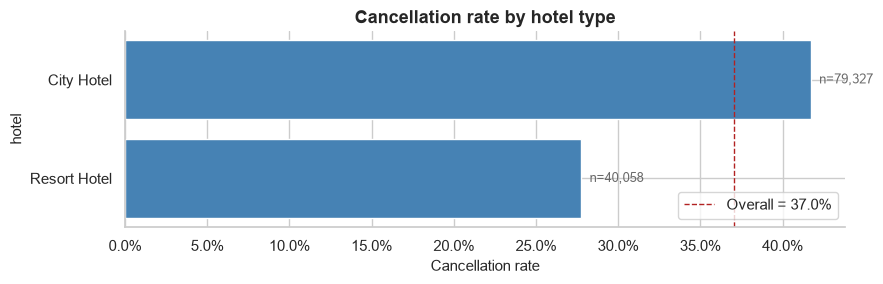

hotel,n_bookings,n_canceled,cancel_rate
Resort Hotel,40058,11121,0.28
City Hotel,79327,33101,0.42


In [9]:
ax, table = plot_cancel_rate(
    df, by='hotel',
    min_n=0,
    title='Cancellation rate by hotel type',
)
plt.tight_layout()
plt.show()

html = table.to_html(index=False).replace(
    '<table', '<table style="display:inline-block;"'
)
display(HTML(f"<br><div style='text-align:center;'>{html}</div>"))

## 1.3. Динамика во времени

Считаем долю отмен по (год x месяц). Смотрим:
- **График A (линии по годам)** - есть ли устойчивая сезонность, повторяется ли рисунок из года в год.
- **График B (heatmap)** - детальный вид «месяц x год»: сразу видно периоды и различия между годами.

In [10]:
dyn = cancel_rate_table(df, ['arrival_date_year', 'arrival_date_month'])
dyn.head()

,arrival_date_year,arrival_date_month,n_bookings,n_canceled,cancel_rate
0,2015,July,2775,1258,0.45
1,2017,May,6313,2762,0.44
2,2017,April,5661,2463,0.44
3,2017,June,5647,2439,0.43
4,2015,August,3889,1598,0.41


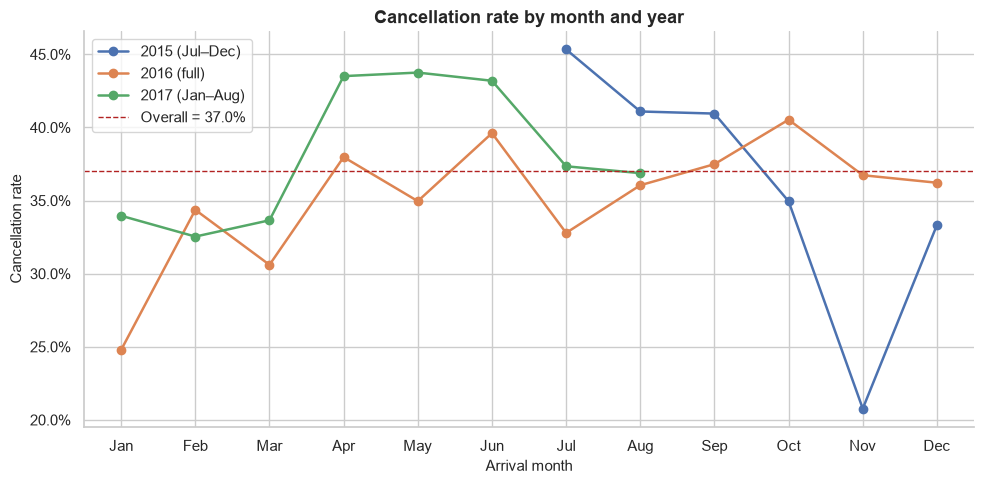

In [11]:
MONTHS_SHORT = [m[:3] for m in MONTHS_ORDER]

dyn['month_num'] = dyn['arrival_date_month'].cat.codes

year_labels = {}
for year, sub in dyn.groupby('arrival_date_year', observed=True):
    months = (sub['arrival_date_month']
              .dropna()
              .drop_duplicates()
              .sort_values()                  
              .astype(str)
              .tolist())
    if len(months) == 12:
        span = 'full'
    else:
        span = f'{months[0][:3]}–{months[-1][:3]}'  
    year_labels[year] = f'{year} ({span})'


fig, ax = plt.subplots(figsize=(10, 5))

for year, sub in dyn.groupby('arrival_date_year', observed=True):
    sub = sub.sort_values('month_num')             
    ax.plot(
        sub['month_num'],                        
        sub['cancel_rate'],
        marker='o',
        linewidth=1.8,
        label=year_labels[year],
    )


overall = df['is_canceled'].mean()
ax.axhline(
    overall,
    color='firebrick',
    linestyle='--',
    linewidth=1,
    label=f'Overall = {overall:.1%}',
)

ax.set_xticks(range(12))
ax.set_xticklabels(MONTHS_SHORT)
ax.set_xlim(-0.5, 11.5)   

ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel('Arrival month')
ax.set_ylabel('Cancellation rate')
ax.set_title('Cancellation rate by month and year')
ax.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

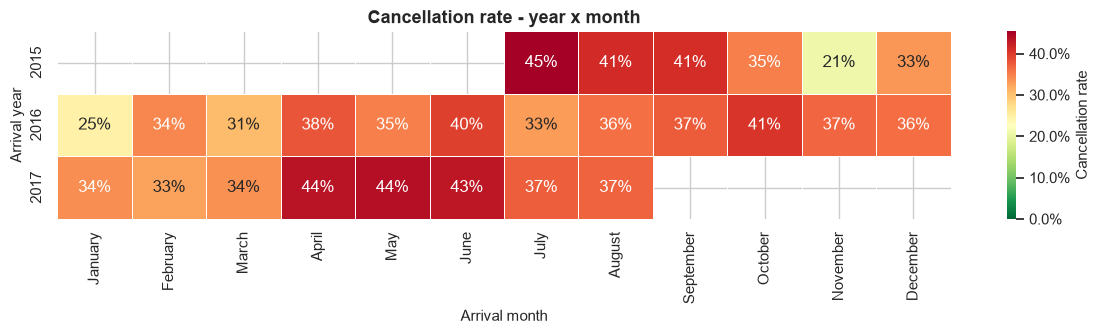

In [31]:
heat = (
    dyn.pivot(index='arrival_date_year',
              columns='arrival_date_month',
              values='cancel_rate')
)

fig, ax = plt.subplots(figsize=(12, 3.5))
sns.heatmap(
    heat,
    annot=True, fmt='.0%',
    cmap='RdYlGn_r',
    vmin=0, vmax=heat.max().max(),
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Cancellation rate', 'format': mticker.PercentFormatter(1.0)},
    ax=ax,
)
ax.set_xlabel('Arrival month')
ax.set_ylabel('Arrival year')
ax.set_title('Cancellation rate - year x month')
plt.tight_layout()
plt.show()

## 1.4. Вывод по BQ1

- **Масштаб.** 37% - системная характеристика, а не «шум».
  44 222 отменённых броней из 119 385.
- **Два разных отеля.** City (42%) отменяется в 1.5 раза чаще Resort (28%).
- **Сезонность - есть, но нестабильная.** Рисунок отмен меняется год к году:<br>
    - 2016 даёт два пика (Apr–Jun, Oct)
    - 2017 - один (Apr–Jun)
    - 2015 обваливается в ноябре (21%) вопреки тренду.
Значит, корень проблемы не в сезонности как таковой.
- **2017 Q2 выше 2016 Q2** (44% и 38%) - возможный тренд роста отмен, требует отдельной проверки.
- **Ограничение.** 2015 и 2017 неполные - прямые годовые сравнения некорректны, но помесячные паттерны внутри каждого года видеть можно.
- **Заметки к BQ2:** раз сезонность «рваная», значит дело в структурных факторах. Проверим `lead_time`, день недели и повторные брони - то, что управляется политикой отеля.

# BQ2. Когда отменяют чаще?

Три среза «когда»:
- **2.1 `lead_time`** - за сколько дней до заезда бронируют «отменяемые» гости.
- **2.2 День недели приезда** - есть ли «плохие» дни.
- **2.3 `lead_time` x месяц** - управляемо ли отменяемое поведение по сезону.

Сезонность по месяцам уже разобрана в BQ1.

## 2.1. `lead_time`

`lead_time` - число дней между бронированием и заездом.<br>
Гипотеза: чем раньше бронь, тем выше шанс, что планы поменяются.<br>

Смотрим два угла:
1. **Распределение** - отличается ли `lead_time` у отменённых и неотменённых броней.
2. **Доля отмены по корзинам** - в каком сегменте lead_time больше всего отмен.

In [13]:
LEAD_BINS   = [0, 1, 7, 14, 30, 60, 90, 180, 365, np.inf]
LEAD_LABELS = ['0', '1–7', '8–14', '15–30', '31–60',
               '61–90', '91–180', '181–365', '365+']

df['lead_time_bin'] = pd.cut(
    df['lead_time'],
    bins=LEAD_BINS,
    labels=LEAD_LABELS,
    right=True,
    include_lowest=True,
).cat.as_ordered()

lead_stats = (
    df.groupby('is_canceled')['lead_time']
      .describe()[['count', 'mean', '50%', '75%', 'max']]
      .rename(columns={'50%': 'median', '75%': 'q75'})
      .round(1)
)
lead_stats.index = lead_stats.index.map({0: 'not canceled', 1: 'canceled'})
lead_stats

,count,mean,median,q75,max
is_canceled,,,,,
not canceled,"75,163.00",80.00,45.00,124.00,737.00
canceled,"44,222.00",144.90,113.00,214.00,629.00


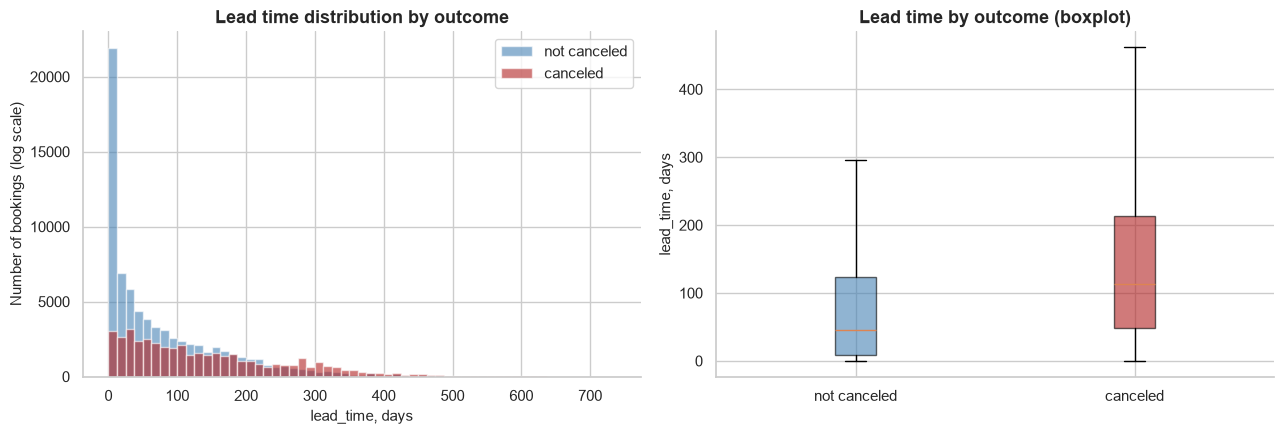

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bins = np.linspace(0, df['lead_time'].max(), 60)
axes[0].hist(
    df.loc[df['is_canceled'] == 0, 'lead_time'],
    bins=bins, alpha=0.6, label='not canceled', color='steelblue',
)
axes[0].hist(
    df.loc[df['is_canceled'] == 1, 'lead_time'],
    bins=bins, alpha=0.6, label='canceled', color='firebrick',
)          
axes[0].set_xlabel('lead_time, days')
axes[0].set_ylabel('Number of bookings (log scale)')
axes[0].set_title('Lead time distribution by outcome')
axes[0].legend()

box_data = [
    df.loc[df['is_canceled'] == 0, 'lead_time'],
    df.loc[df['is_canceled'] == 1, 'lead_time'],
]
bp = axes[1].boxplot(
    box_data,
    tick_labels=['not canceled', 'canceled'],
    patch_artist=True,
    showfliers=False,
)
for patch, color in zip(bp['boxes'], ['steelblue', 'firebrick']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_ylabel('lead_time, days')
axes[1].set_title('Lead time by outcome (boxplot)')

plt.tight_layout()
plt.show()

## 2.1. Вывод

- **Медиана `lead_time`**: 45 дней у неотменённых и 113 дней у отменённых - в 2.5 раза больше. Сдвиг происходит на всём распределении, а не только в «хвосте» (Q75: 124 и 214).
- **Практический смысл:** типичная отменяемая бронь - «дальняя». Первые ~2 недели до заезда - "безопасны" в плане отмен.
- **Что это меняет:** напоминания и депозитная политика становятся осмысленными именно для длинных lead_time.

## 2.2. День недели приезда

Собираем `arrival_date` из year / month / day_of_month, и получаем день недели.

**Зачем:** Если «плохие» дни - это выходные, значит, причина в типе поездки (короткие weekend). Если это понедельник -
скорее business-брони. Можно получить разные "сигменты" и дать соответствующие рекомендации.

In [36]:
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'].astype(str) + '-' +
    df['arrival_date_day_of_month'].astype(str),
    format='%Y-%B-%d',
    errors='coerce',
)

n_bad = df['arrival_date'].isna().sum()
if n_bad > 0:
    print(f'Unparsed dates: {n_bad:,} of {len(df):,}')

df['arrival_dow'] = df['arrival_date'].dt.day_name()

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['arrival_dow'] = pd.Categorical(df['arrival_dow'], categories=dow_order, ordered=True)

df[['arrival_date', 'arrival_dow']].head(3)

,arrival_date,arrival_dow
0,2015-07-01,Wednesday
1,2015-07-01,Wednesday
2,2015-07-01,Wednesday


In [16]:
dow_table = cancel_rate_table(df, 'arrival_dow')
dow_table

,arrival_dow,n_bookings,n_canceled,cancel_rate
0,Thursday,19254,7927,0.41
1,Friday,19630,7977,0.41
2,Saturday,18055,7129,0.39
3,Wednesday,16139,5831,0.36
4,Monday,18171,6195,0.34
5,Tuesday,13998,4600,0.33
6,Sunday,14138,4563,0.32


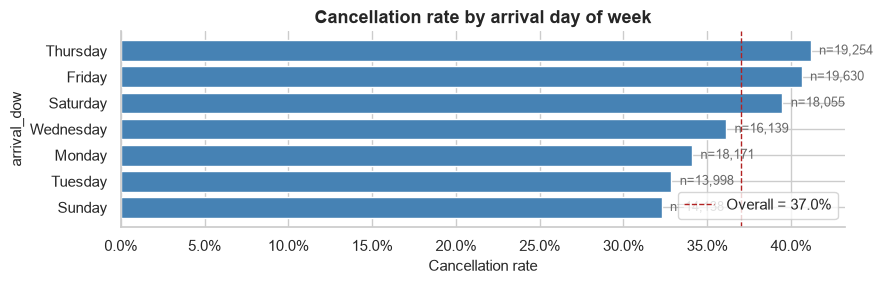

In [17]:
ax, _ = plot_cancel_rate(
    df, by='arrival_dow',
    min_n=0,
    title='Cancellation rate by arrival day of week',
)
plt.tight_layout()
plt.show()

## 2.2. Вывод

- **Разброс по дням недели - 9%:** Thursday/Friday (41%) и Sunday (32%). Все группы n > 13 000.
- **Weekend-эффекта нет.** Суббота в середине (39%), воскресенье - в самом низу (32%). Значит, причина не в выходных.
- **Гипотеза о бизнес-паттерне:** заезды в четверг/пятницу - это либо длинные weekend-поездки, либо командировки с заездом заранее; такие брони оформляются с большим `lead_time` -> выше риск.
- **Практический смысл:** день недели приезда - слабый, но ненулевой. В связке с `lead_time` может стать управляемым рычагом.

Следующий шаг - `lead_time` x месяц. Проверим, «сгущается» ли риск в конкретных месячно-горизонтных зонах.

## 2.3. `lead_time` x месяц (heatmap по годам)

Смотрим, в каком сегменте большой риск: пересечение длинного горизонта брони и сезона приезда.

- **Строки:** корзины `lead_time_bin` (из 2.1).
- **Столбцы:** месяц приезда.
- **Цвет:** доля отмены.
- **Белые клетки:** слишком мало данных (n < 30) - не интерпретируем.

In [18]:
MONTHS_ORDER = ['January','February','March','April','May','June',
                'July','August','September','October','November','December']

MIN_N_CELL = 30
LEAD_BINS_TO_SHOW = list(df['lead_time_bin'].cat.categories)

pivots = {}
vmax_global = 0.0

for year in sorted(df['arrival_date_year'].unique()):
    sub = df[df['arrival_date_year'] == year]

    rate_p = sub.pivot_table(
        index='lead_time_bin',
        columns='arrival_date_month',
        values='is_canceled',
        aggfunc='mean',
        observed=False,
    )

    n_p = sub.pivot_table(
        index='lead_time_bin',
        columns='arrival_date_month',
        aggfunc='size',
        observed=False,
    )

    rate_p = rate_p.reindex(index=LEAD_BINS_TO_SHOW, columns=MONTHS_ORDER)
    n_p    = n_p.reindex(index=LEAD_BINS_TO_SHOW, columns=MONTHS_ORDER).fillna(0)

    rate_p_masked = rate_p.mask(n_p < MIN_N_CELL)

    pivots[year] = (rate_p_masked, n_p)

    if rate_p_masked.notna().any().any():
        local_max = np.nanmax(rate_p_masked.values)
        vmax_global = max(vmax_global, local_max)

print(f'Years: {sorted(int(y) for y in pivots.keys())}')
print(f'Global vmax (for shared colorbar): {vmax_global:.1%}')

Years: [2015, 2016, 2017]
Global vmax (for shared colorbar): 100.0%


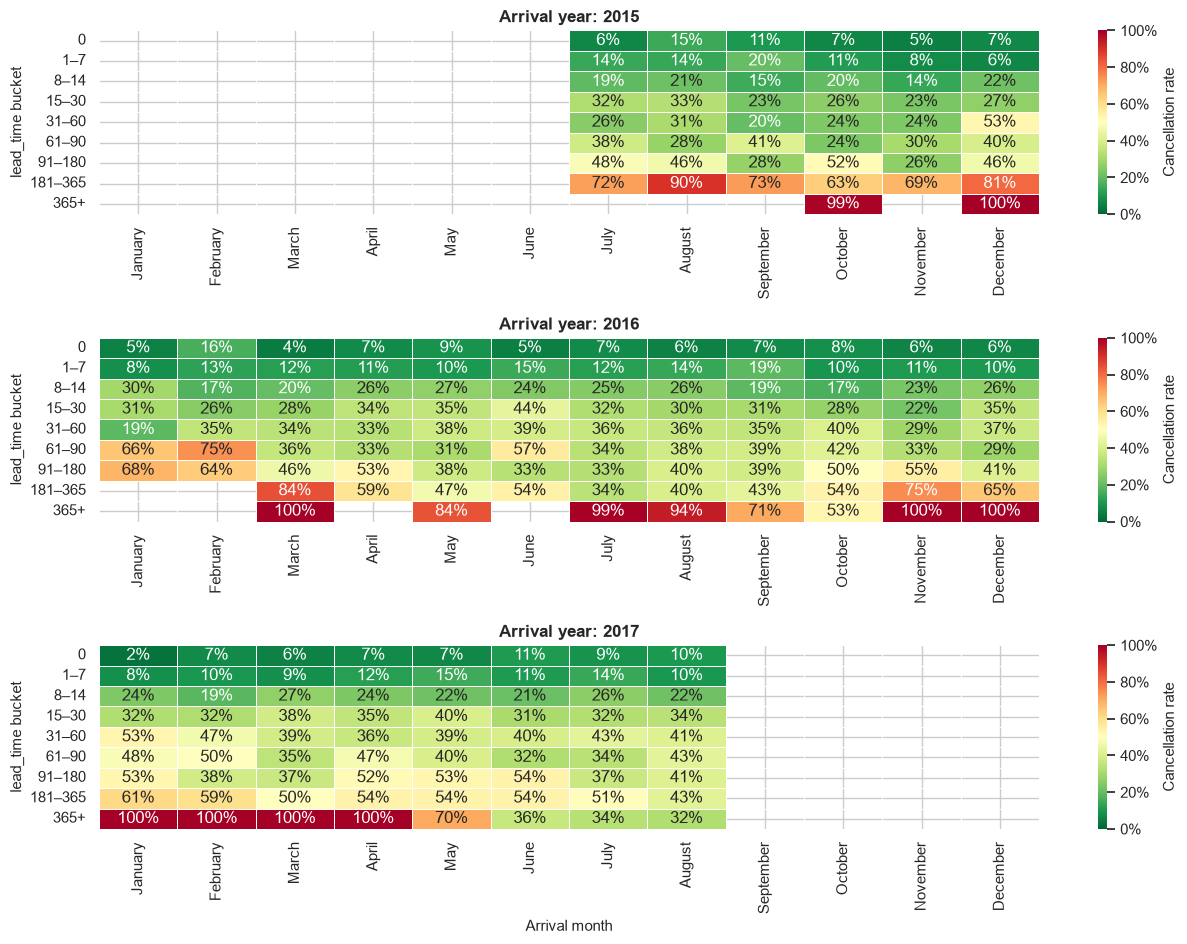

In [19]:
years = sorted(pivots.keys())

fig, axes = plt.subplots(
    nrows=len(years), ncols=1,
    figsize=(13, 3.2 * len(years)),
    sharex=False, sharey=False,
)

for ax, year in zip(axes, years):
    rate_p, n_p = pivots[year]

    sns.heatmap(
        rate_p,
        ax=ax,
        cmap='RdYlGn_r',
        vmin=0, vmax=vmax_global,
        annot=True, fmt='.0%',
        linewidths=0.5, linecolor='white',
        cbar_kws={
            'label': 'Cancellation rate',
            'format': mticker.PercentFormatter(1.0),
        },
    )

    ax.set_title(f'Arrival year: {year}', fontsize=12)
    ax.set_xlabel('Arrival month' if year == years[-1] else '')
    ax.set_ylabel('lead_time bucket')

plt.tight_layout()
plt.show()

## 2.3. Вывод

- **Доминирующий паттерн - не сезонность, а `lead_time`.** В каждом месяце каждого года доля отмен монотонно растёт с горизонтом брони. Месяц лишь немного сдвигает уровень, но не создаёт сам эффект.
- **Две «зоны» отмен:**
  - **Безопасная (0–30 дней):** обычно < 30%, часто < 15%.
  - **Рискованная (365+ дней):** практически 100% отмен во всех годах.
- **Средние горизонты (91–365 дней)** - переходная зона,
  где политика отеля реально может влиять на исход.
- **Ограничения:**
  - Цветовая шкала растянута до 100% из-за экстремальных ячеек в `365+`, мелкие различия в «зелёной» зоне визуально недооценены.
  - Сезонные различия внутри одного года видны, но делать вывод «в месяце X отменяют больше» на одном годе некорректно.

К BQ3: если доминирует `lead_time`, то стоит посмотреть профиль брони за год вперёд.

# BQ3. Кто отменяет чаще?

Разбираем «кто» через категориальные разрезы:
- 3.1 `market_segment` - рыночный сегмент.
- 3.2 `customer_type` + `distribution_channel` - тип клиента и канал брони.
- 3.3 `is_repeated_guest` - повторные и новые гости.
- 3.4 Топ-15 стран по объёму.
- 3.5 Пересечения: `hotel x market_segment`, `hotel x deposit_type`.

Везде сравниваем **доли**, а не абсолютные числа: большие группы доминируют в абсолютных числах, и это искажает восприятие.

In [20]:
seg_table = cancel_rate_table(df, 'market_segment', min_n=100)
seg_table

,market_segment,n_bookings,n_canceled,cancel_rate
0,Groups,19810,12097,0.61
1,Online TA,56476,20739,0.37
2,Offline TA/TO,24217,8309,0.34
3,Aviation,237,52,0.22
4,Corporate,5294,992,0.19
5,Direct,12606,1934,0.15
6,Complementary,743,97,0.13


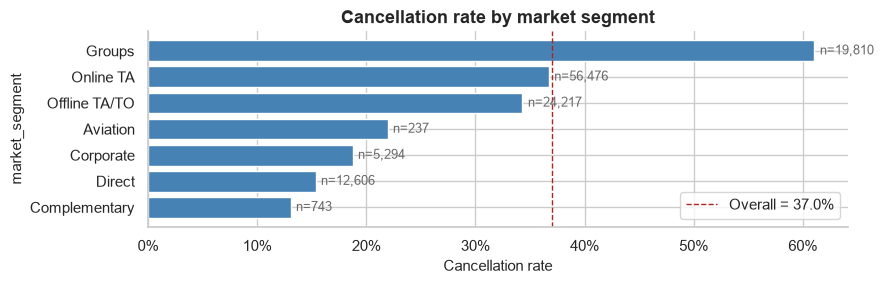

In [21]:
plot_cancel_rate(
    df, by='market_segment', min_n=100,
    title='Cancellation rate by market segment',
)
plt.tight_layout()
plt.show()

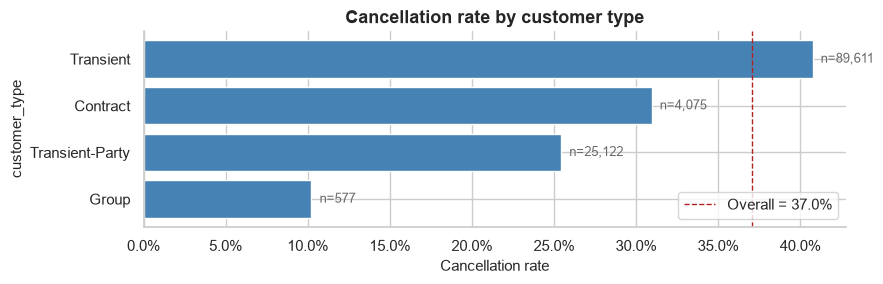

In [22]:
plot_cancel_rate(
    df, by='customer_type', min_n=100,
    title='Cancellation rate by customer type',
)
plt.tight_layout()
plt.show()

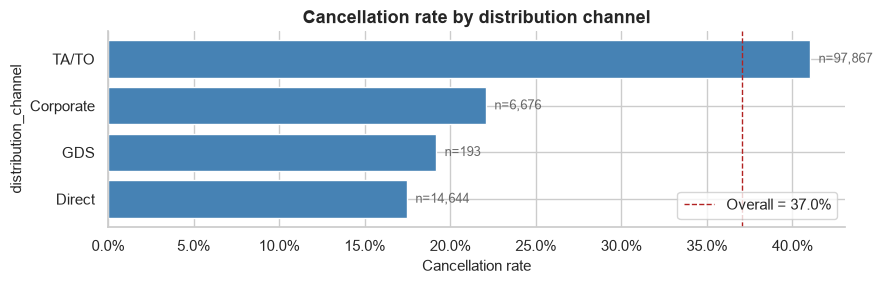

In [23]:
plot_cancel_rate(
    df, by='distribution_channel', min_n=100,
    title='Cancellation rate by distribution channel',
)
plt.tight_layout()
plt.show()

In [24]:
df['guest_type'] = (
    df['is_repeated_guest']
      .map({0: 'new', 1: 'returning'})
      .astype('category')
)

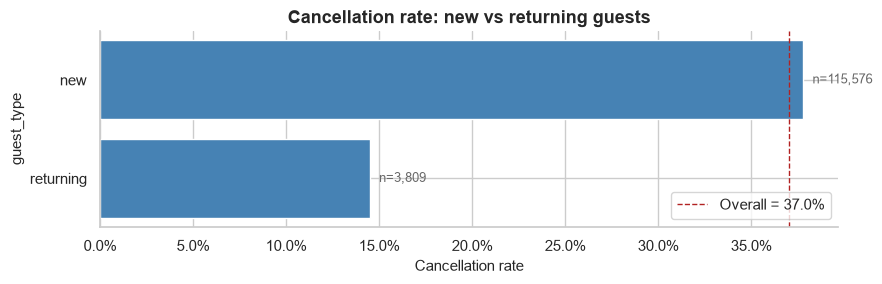

In [37]:
plot_cancel_rate(
    df, by='guest_type', min_n=0,
    title='Cancellation rate: new vs returning guests',
)
plt.tight_layout()
plt.show()

## 3.1–3.3. Вывод

- **Groups (market_segment) - 61% отмен, разрыв в 4.7 раза с Direct (15%).** Это главный сигнал сегментного разреза.
- **Примичание:** `customer_type = Group` показывает **10%** - противоположный результат. Это разные переменные с похожими именами. Groups-сегмент - это групповые брони, часто через TA/TO; Group-тип - формальная классификация брони, скорее корпоративная.
- **Direct и Corporate - «зелёная зона»** и по сегменту (15–19%), и по каналу (17–22%). TA/TO - источник основной массы отмен.
- **Повторные гости - 14% против 37% у новых.** В 2.6 раза реже отменяют. Также является сигналом для дальнейшего анализа.
- **Практический смысл:** Direct-брони и повторные гости - не только дешевле в привлечении, но и надёжнее по отменам. Это делает лояльность и прямые каналы экономически выгодными.

In [39]:
top_countries = (
    df['country'].value_counts()
      .head(15)
      .index
      .tolist()
)

country_table = cancel_rate_table(df, 'country', min_n=0)
country_table = (
    country_table[country_table['country'].isin(top_countries)]
    .sort_values('n_bookings', ascending=False)
    .reset_index(drop=True)
)
country_table.head(7)

,country,n_bookings,n_canceled,cancel_rate
0,PRT,48587,27517,0.57
1,GBR,12127,2453,0.20
2,FRA,10415,1934,0.19
3,ESP,8568,2177,0.25
4,DEU,7287,1218,0.17
5,ITA,3766,1333,0.35
6,IRL,3375,832,0.25


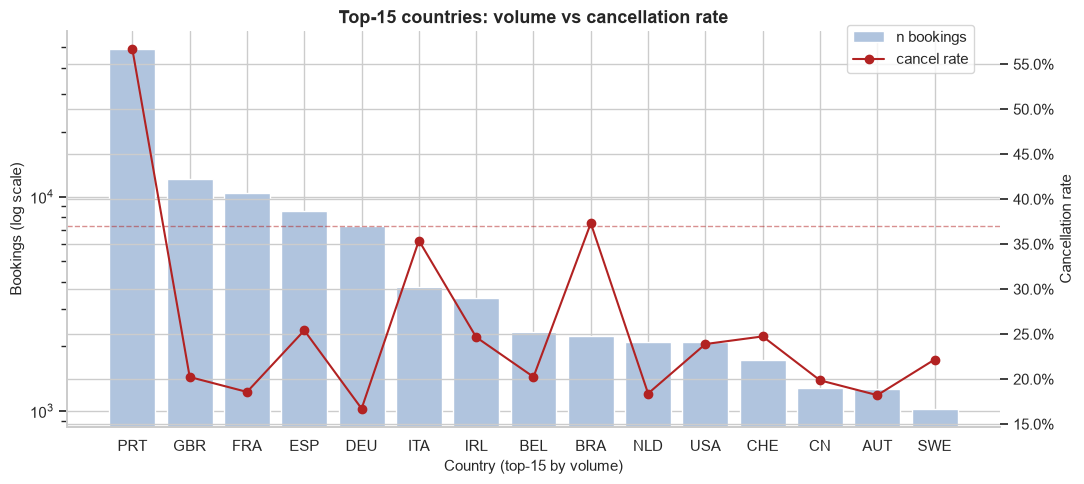

In [27]:
fig, ax1 = plt.subplots(figsize=(11, 5))

x = np.arange(len(country_table))
ax1.bar(x, country_table['n_bookings'], color='lightsteelblue', label='n bookings')
ax1.set_yscale('log')
ax1.set_ylabel('Bookings (log scale)')
ax1.set_xticks(x)
ax1.set_xticklabels(country_table['country'], rotation=0)
ax1.set_xlabel('Country (top-15 by volume)')

ax2 = ax1.twinx()
ax2.plot(x, country_table['cancel_rate'], color='firebrick',
         marker='o', linewidth=1.5, label='cancel rate')
ax2.axhline(df['is_canceled'].mean(), color='firebrick',
            linestyle='--', linewidth=1, alpha=0.5)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.set_ylabel('Cancellation rate')

ax1.set_title('Top-15 countries: volume vs cancellation rate')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.95))
plt.tight_layout()
plt.show()

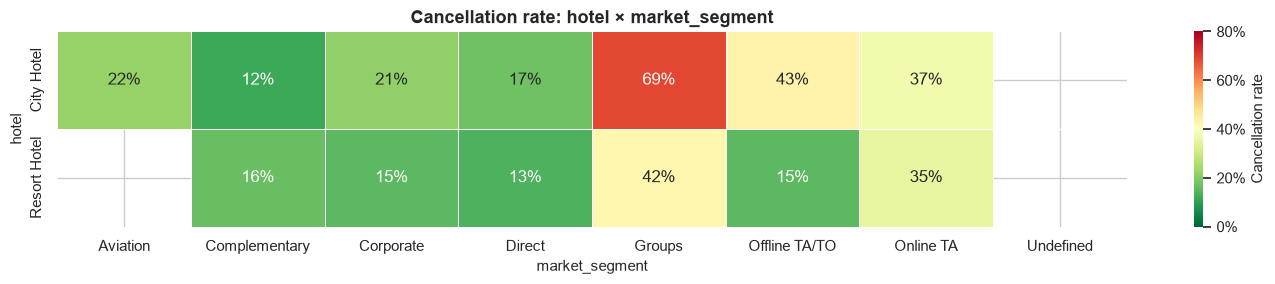

In [29]:
cancel_heatmap(df, index='hotel', columns='market_segment', min_n=100)
plt.tight_layout()
plt.show()

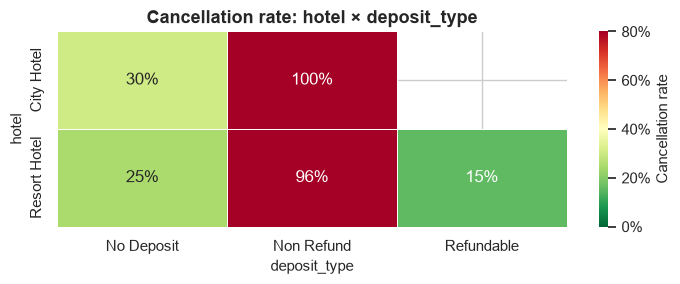

In [30]:
cancel_heatmap(df, index='hotel', columns='deposit_type', min_n=100)
plt.tight_layout()
plt.show()

## 3.6. Вывод по BQ3

**Кто отменяет чаще (по доле):**
- **Groups (market_segment)** - 61%. Direct - 15%. Разрыв в 4.7 раза.
- **Transient (customer_type)** - 40%.
- **TA/TO (distribution_channel)** - 37% (при 82% объёме).
- **Новые гости** - 37%, повторные - 14% (в 2.6 раз реже).
- **PRT** - 57% при 41% всех броней; остальные страны ровным фоном 17-25%.

**Два ключевых взаимодействия (из 3.5):**
1. **Groups x City = 69%.** Эффект «Groups» усиливается в City Hotel. В Resort Groups «всего» 42% (против 28% общий по Resort). То есть очень высокий Groups-риск - это феномен City-модели.
2. **Non Refund x City = 100% и x Resort = 96%.** Парадокс Non Refund визуально подтверждается.

**Три ключевых наблюдения высокого риска:**
- Groups + City.
- Non Refund (deposit_type).
- PRT как концентрация риска.

**Возможные рекомендации:**
- Direct-канал и возвращающиеся гости - «зелёная зона» (15-17% и 14%), но малые объёмы: развитие требует стимулов.
- Groups x City - приоритет №1 по управлению риском (69% при 19k броней).
- PRT - стоит обратить внимение на "домашний" рынок.

**Примичание:**
- `market_segment = Groups` (61% отмен) <> `customer_type = Group` (10% отмен). Это разные переменные с похожими именами. Формулировка «Groups отменяет чаще» верна только для market_segment.